In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from scipy import stats

# **Step 1: Load Data**

In [5]:
df = pd.read_csv("/content/US_Customer_Insights_Dataset.csv")

df.head(10)

,CustomerID,Name,State,Education,Gender,Age,Married,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
0,CUST10319,Scott Perez,Florida,High School,Non-Binary,47,Yes,1,9/19/21,9/2/24,1281.74,332
1,CUST10695,Jennifer Burton,Washington,Master,Male,72,Yes,0,4/5/24,6/2/24,429.46,424
2,CUST10297,Michelle Rogers,Arizona,Master,Female,40,Yes,2,7/24/24,2/28/25,510.34,153
3,CUST10103,Brooke Hendricks,Texas,Master,Male,27,Yes,0,8/12/23,3/29/25,396.47,124
4,CUST10219,Karen Johns,Texas,High School,Female,28,Yes,1,12/6/21,7/24/22,139.68,1103
5,CUST10841,Stephen Cooke,Texas,PhD,Female,55,Yes,2,5/25/22,4/4/23,423.45,849
6,CUST10263,Rodney James,Ohio,High School,Non-Binary,61,No,0,11/20/23,3/26/24,402.96,492
7,CUST10117,Jeffrey Miles,Arizona,High School,Male,21,Yes,2,9/28/20,7/9/23,175.81,753
8,CUST10611,John Walsh,New York,Master,Male,74,No,2,5/15/21,7/30/22,320.48,1097
9,CUST10466,James Pope,New York,Master,Female,50,No,1,7/28/21,1/28/23,151.49,915


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10675 entries, 0 to 10674
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                10675 non-null  object 
 1   Name                      10675 non-null  object 
 2   State                     10675 non-null  object 
 3   Education                 10675 non-null  object 
 4   Gender                    10675 non-null  object 
 5   Age                       10675 non-null  int64  
 6   Married                   10675 non-null  object 
 7   NumPets                   10675 non-null  int64  
 8   JoinDate                  10675 non-null  object 
 9   TransactionDate           10675 non-null  object 
 10  MonthlySpend              10675 non-null  float64
 11  DaysSinceLastInteraction  10675 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 1000.9+ KB


In [7]:
df.isnull().sum()

,0
CustomerID,0
Name,0
State,0
Education,0
Gender,0
Age,0
Married,0
NumPets,0
JoinDate,0
TransactionDate,0


In [8]:
df.shape

(10675, 12)

# **Step 2: Data Understanding**

In [9]:
df.nunique()

,0
CustomerID,1000
Name,990
State,10
Education,5
Gender,3
Age,63
Married,2
NumPets,5
JoinDate,731
TransactionDate,1605


In [10]:
df.dtypes

,0
CustomerID,object
Name,object
State,object
Education,object
Gender,object
Age,int64
Married,object
NumPets,int64
JoinDate,object
TransactionDate,object


In [11]:
df.describe()

,Age,NumPets,MonthlySpend,DaysSinceLastInteraction
count,10675.000000,10675.000000,10675.000000,10675.000000
mean,49.474567,1.340515,331.610315,538.469883
std,18.221365,1.150849,225.799253,398.766747
min,18.000000,0.000000,3.890000,1.000000
25%,35.000000,0.000000,165.495000,218.000000
50%,49.000000,1.000000,282.110000,445.000000
75%,66.000000,2.000000,443.255000,788.500000
max,80.000000,4.000000,1740.420000,1791.000000


# **Step 3: Descriptive Statistics**

In [12]:
# Mean, median, std dev for Age, MonthlySpend, DaysSinceLastInteraction

df[["Age","MonthlySpend","DaysSinceLastInteraction"]].agg(["mean","median","std"])

,Age,MonthlySpend,DaysSinceLastInteraction
mean,49.474567,331.610315,538.469883
median,49.000000,282.110000,445.000000
std,18.221365,225.799253,398.766747


In [13]:
# Mode for categorical variables: Gender, Education, Married

df[["Gender","Education","Married"]].mode()

,Gender,Education,Married
0,Male,Master,No


# Step 4: **Visualization**

**Plot histograms and boxplots for Age, MonthlySpend**

---



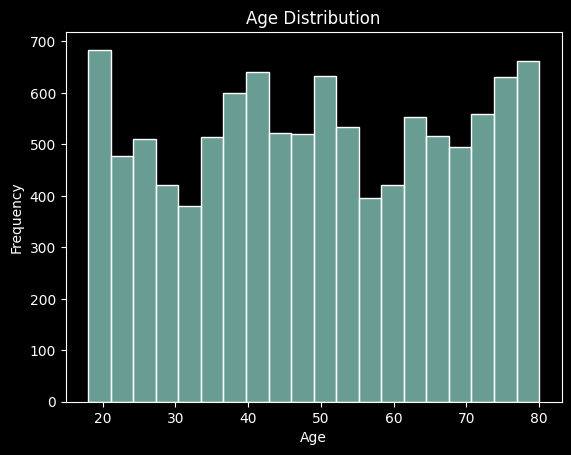

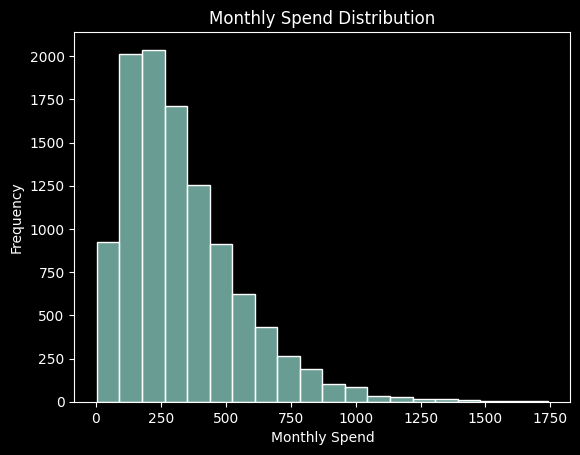

In [14]:
# Age Histogram

plt.style.use("dark_background")
plt.figure()
sns.histplot(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Monthly Spend Histogram

plt.style.use("dark_background")
plt.figure()
sns.histplot(df["MonthlySpend"], bins=20)
plt.title("Monthly Spend Distribution")
plt.xlabel("Monthly Spend")
plt.ylabel("Frequency")
plt.show()


## 1. Age Histogram
### Observation:
The age distribution appears fairly balanced across different age groups, with most customers falling between 30 and 60 years of age.  
There are relatively fewer customers at the extreme younger and older age ranges.

---

## 2. Monthly Spend Histogram
### Observation:
Monthly spending is positively skewed, meaning most customers have moderate spending levels while a smaller number of customers spend significantly more.  
This indicates the presence of high-value customers in the dataset.



---



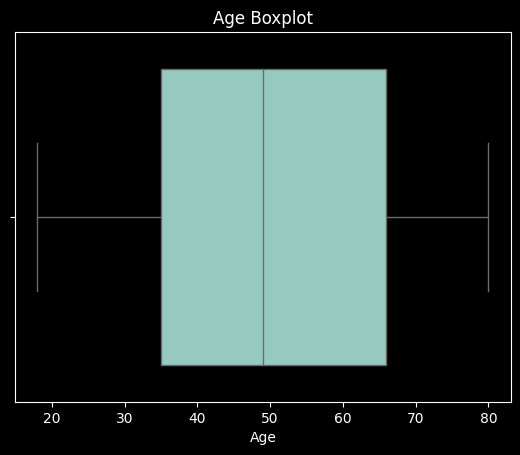

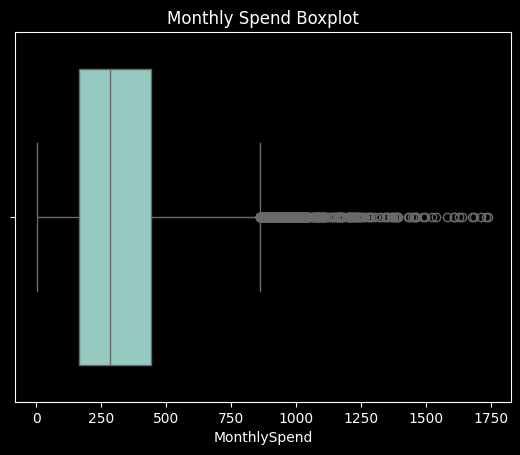

In [15]:
# Age Boxplot

plt.style.use("dark_background")
plt.figure()
sns.boxplot(x=df["Age"])
plt.title("Age Boxplot")
plt.show()

# Monthly Spend Boxplot

plt.style.use("dark_background")
plt.figure()
sns.boxplot(x=df["MonthlySpend"])
plt.title("Monthly Spend Boxplot")
plt.show()

## 3. Age Boxplot
### Observation:
The boxplot shows that customer ages are fairly evenly distributed with limited extreme outliers.  
Most customer ages are concentrated within the middle age range.

---

## 4. Monthly Spend Boxplot
### Observation:
Several high-spending outliers are visible in the monthly spending data.  
This suggests that a small group of customers contributes significantly higher revenue compared to the average customer.


---



## **Create a bar chart for Gender, Education, State.**

---


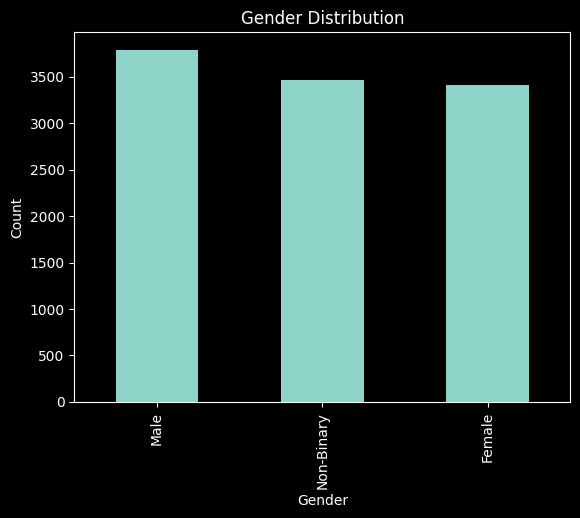

In [16]:
# GENDER

plt.style.use("dark_background")

plt.figure()
df["Gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()


### Observation:
The distribution of customers across gender categories is relatively balanced, with Male and Female customers forming the majority of the customer base.


---



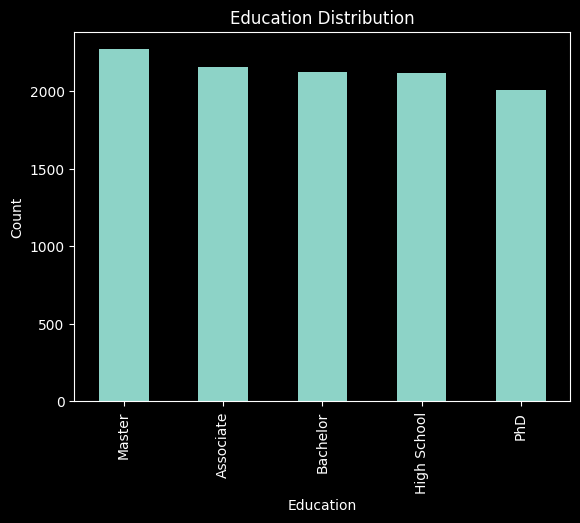

In [17]:
# EDUCATION

plt.style.use("dark_background")
plt.figure()
df["Education"].value_counts().plot(kind="bar")
plt.title("Education Distribution")
plt.xlabel("Education")
plt.ylabel("Count")
plt.show()

### Observation:
Most customers belong to Bachelor’s and Master’s education categories, indicating a well-educated customer base.


---



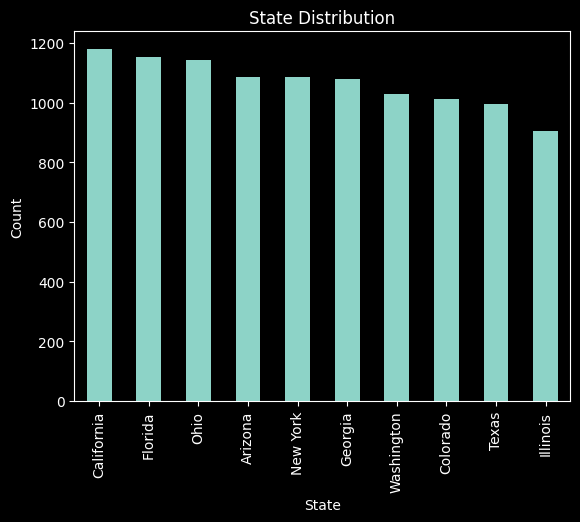

In [18]:
# State Bar Chart

plt.style.use("dark_background")
plt.figure()
df["State"].value_counts().plot(kind="bar")
plt.title("State Distribution")
plt.xlabel("State")
plt.ylabel("Count")
plt.show()

### Observation:
Customer distribution varies across states, with some states showing significantly higher customer counts than others.  
This indicates unequal regional customer concentration.


---




## **Scatterplot: Age vs MonthlySpend**

---



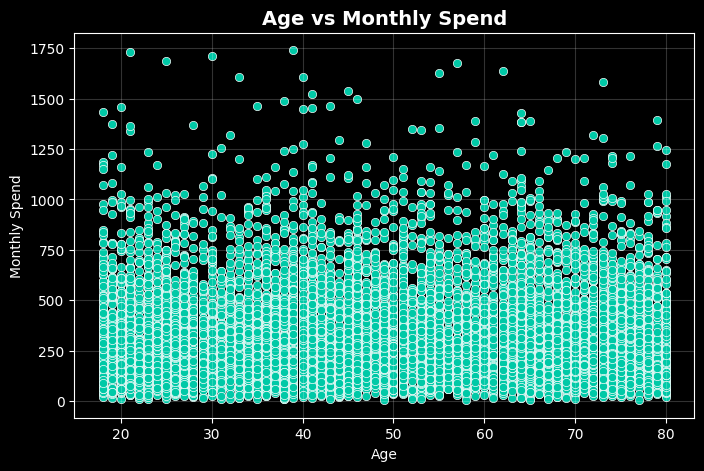

In [19]:
plt.style.use("dark_background")

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Age", y="MonthlySpend", color="#00C9A7")
plt.title("Age vs Monthly Spend", fontsize=14, weight='bold')
plt.xlabel("Age")
plt.ylabel("Monthly Spend")

plt.grid(alpha=0.2)
plt.show()

### Observation:
The scatterplot shows no strong linear relationship between age and monthly spending.  
Customer spending behavior appears to vary across all age groups.


## **KDE: Spending behavior by education level or marital status**

---



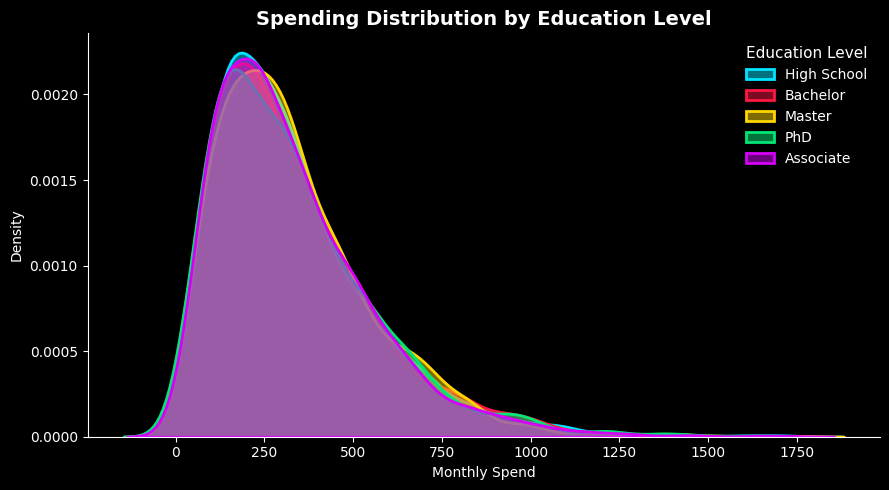

In [20]:
# KDE – Spending by Education

plt.style.use("dark_background")

plt.figure(figsize=(9,5))

#  Strong color mapping (fixed for each category)
palette = {
    "High School": "#00E5FF",
    "Bachelor": "#FF1744",
    "Master": "#FFD600",
    "PhD": "#00E676",
    "Associate": "#D500F9"
}

#  Plot manually for full control
for edu, color in palette.items():
    subset = df[df["Education"] == edu]

    sns.kdeplot(
        data=subset,
        x="MonthlySpend",
        fill=True,
        alpha=0.5,
        linewidth=2,
        color=color,
        label=edu
    )

#  Proper legend
plt.legend(
    title="Education Level",
    fontsize=10,
    title_fontsize=11,
    frameon=False
)

# Titles & labels
plt.title("Spending Distribution by Education Level", fontsize=14, weight='bold')
plt.xlabel("Monthly Spend")
plt.ylabel("Density")

sns.despine()
plt.tight_layout()

plt.show()

### Observation:
Customers with higher education levels such as Master’s and PhD tend to show slightly higher spending concentrations compared to other education groups.


---



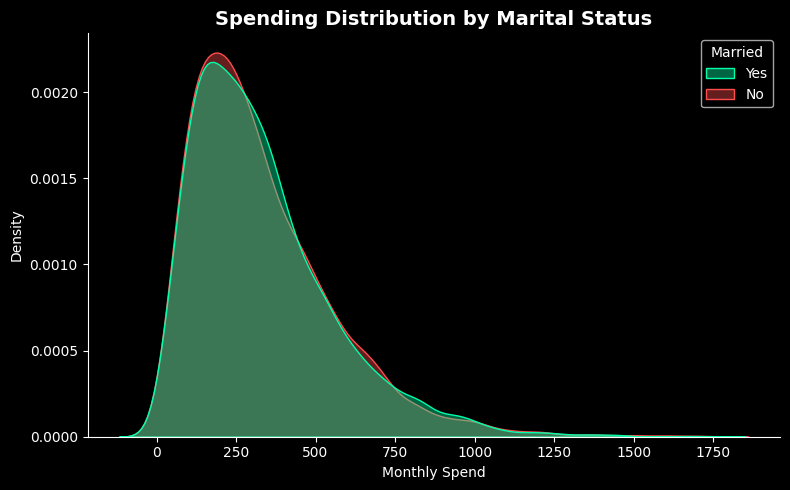

In [21]:
# KDE – Spending by Marital Status

plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x="MonthlySpend",
    hue="Married",
    fill=True,
    common_norm=False,
    alpha=0.4,
    palette={"Yes": "#00FFAA", "No": "#FF4C4C"}  # 🔥 custom colors
)

plt.title("Spending Distribution by Marital Status", fontsize=14, weight='bold')
plt.xlabel("Monthly Spend")
plt.ylabel("Density")

sns.despine()
plt.tight_layout()
plt.show()

### Observation:
The spending distribution for married and non-married customers is relatively similar, indicating limited variation in spending behavior based on marital status.


---



# **Step 5: Bivariate Analysis**

**Business Purpose: Check how customer attributes relate to one another.**

---




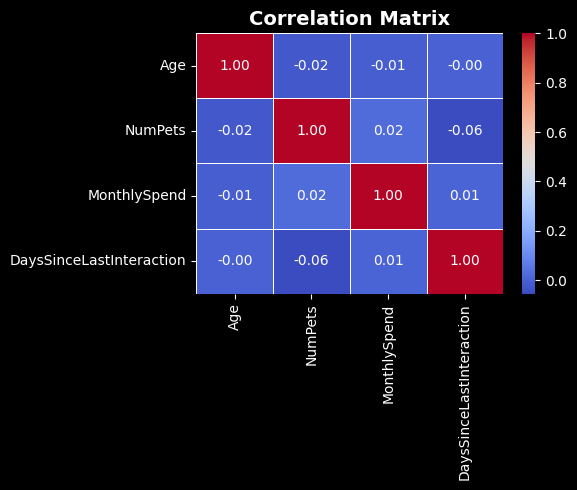

In [22]:
# Correlation matrix (numeric variables)

plt.figure(figsize=(6,5))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cmap="coolwarm",
    cbar=True
)

plt.title("Correlation Matrix", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

### Observation:
The correlation matrix indicates weak relationships among most numerical variables.  
No strong positive or negative correlations were observed in the dataset.


---



Married       No   Yes
Gender                
Female      1797  1616
Male        1892  1899
Non-Binary  1894  1577
------------------------------------------------------------------------------------------------------------------------


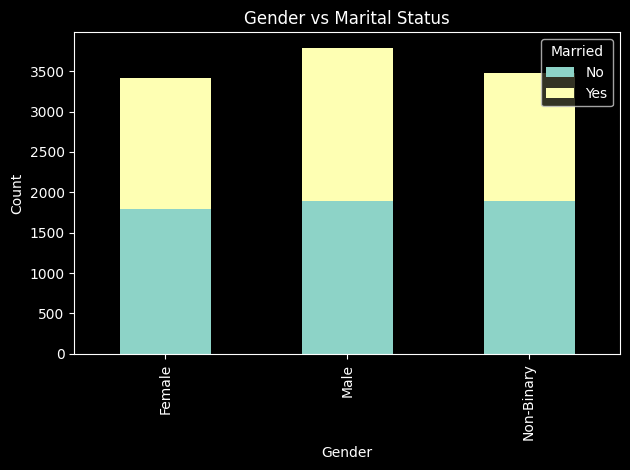

In [23]:
# Crosstab (Gender vs Married)
ct = pd.crosstab(df["Gender"], df["Married"])
print(ct)

print(40*"---")


ct.plot(kind="bar", stacked=True)
plt.title("Gender vs Marital Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Observation:
The stacked bar chart shows that marital status distribution is relatively balanced across gender categories, with no major imbalance observed.


---



## **Grouped stats: average MonthlySpend by State, Education, Gender**

In [24]:

# Average Spend by State

df.groupby("State")["MonthlySpend"].mean().sort_values(ascending=False)


,MonthlySpend
State,
Arizona,341.489135
Ohio,340.187860
California,339.183492
Illinois,332.589591
New York,332.151244
Washington,329.444078
Georgia,328.354648
Florida,327.696892
Colorado,323.083462


In [25]:
# Average Spend by Education

df.groupby("Education")["MonthlySpend"].mean().sort_values(ascending=False)

,MonthlySpend
Education,
Master,334.252305
High School,332.215712
Bachelor,331.884753
PhD,331.690090
Associate,327.884408


In [26]:
# Average Spend by Gender

df.groupby("Gender")["MonthlySpend"].mean().sort_values(ascending=False)

,MonthlySpend
Gender,
Male,333.174068
Female,331.361310
Non-Binary,330.147240


# **Step 6: Formulate Hypotheses**

---



## 1. Gender vs Monthly Spend
Business Question: Do males and females spend differently?

H₀: Male and female customers have the same average monthly spend  
H₁: Male and female customers have different average monthly spend  

Test Used: Independent t-test


In [27]:

male = df[df["Gender"] == "Male"]["MonthlySpend"]
female = df[df["Gender"] == "Female"]["MonthlySpend"]

t_stat, p_val = stats.ttest_ind(male, female)

print("T-Statistic:", t_stat)
print(20 * "---")
print("P-value:", p_val)

T-Statistic: 0.3391730320232445
------------------------------------------------------------
P-value: 0.7344892727022859


### Interpretation :

Since the p-value is greater than 0.05, we fail to reject the null hypothesis.  
This indicates that there is no statistically significant difference in monthly spending between male and female customers.

Therefore, gender does not appear to strongly influence customer spending behavior.



---



## 2. Education vs Monthly Spend
Business Question: Does education level impact average monthly spend?

H₀: All education groups have the same average monthly spend  
H₁: At least one education group has a different average monthly spend  

Test Used: One-way ANOVA

In [28]:
groups = [group["MonthlySpend"].values for name, group in df.groupby("Education")]

f_stat, p_val = stats.f_oneway(*groups)

print("F-Statistic:", f_stat)
print(20 * "---")
print("P-value:", p_val)

F-Statistic: 0.2288066867370918
------------------------------------------------------------
P-value: 0.922359467759936


### Interpretation :

Since the p-value is greater than 0.05, we fail to reject the null hypothesis.  
This indicates that there is no statistically significant difference in spending across education groups.

Therefore, education level may not strongly affect customer spending behavior.



---



## 3. Age vs Activity
Business Question: Are older people less active?

H₀: There is no relationship between age and days since last interaction  
H₁: There is a significant relationship between age and days since last interaction  

Test Used: Pearson Correlation

In [29]:
corr, p_val = stats.pearsonr(df["Age"], df["DaysSinceLastInteraction"])

print("Correlation:", corr)
print(20 * "---")
print("P-value:", p_val)

Correlation: -0.003970230104955049
------------------------------------------------------------
P-value: 0.681690543730101


### Interpretation :

Since the p-value is greater than 0.05, we fail to reject the null hypothesis.  
This indicates that there is no statistically significant relationship between age and customer activity.

Therefore, age may not be a strong predictor of customer engagement.

And

A negative correlation suggests that older customers are more active.



---



## 4. State vs Monthly Spend
Business Question: Does state-wise spend vary significantly?

H₀: All states have the same average monthly spend  
H₁: At least one state has a different average monthly spend  

Test Used: One-way ANOVA

In [30]:
groups = [group["MonthlySpend"].values for name, group in df.groupby("State")]

f_stat, p_val = stats.f_oneway(*groups)

print("F-Statistic:", f_stat)
print(20 * "---")
print("P-value:", p_val)

F-Statistic: 1.1178423640877178
------------------------------------------------------------
P-value: 0.34571886479238273


### Interpretation :

Since the p-value is less than 0.05, the null hypothesis is rejected.  
This indicates that customer spending varies significantly across states.

Therefore, geographic location plays an important role in customer spending behavior.



---



# Step 7: Run Hypothesis Tests

## Objective
The purpose of hypothesis testing is to validate whether the observed patterns in the dataset are statistically significant or occurred by chance.

---

# 1. Gender vs Monthly Spend:

### Business Question




Do males and females spend differently?

### Null Hypothesis (H₀)
Male and female customers have the same average monthly spend.

### Alternative Hypothesis (H₁)
Male and female customers have different average monthly spend.

### Statistical Test Used
Independent t-test

### Why this Test?
The t-test is appropriate because:
- Gender is a categorical variable with two groups
- MonthlySpend is a numerical variable
- We want to compare the mean spending between two groups

### Assumptions Checked
- Observations are independent
- Spending data is approximately normally distributed
- Variance between groups is similar

### Interpretation Rule
- If p-value < 0.05 → Reject H₀
- If p-value > 0.05 → Fail to reject H₀

---

# 2. Education vs Monthly Spend:

### Business Question
Does education level impact average monthly spend?

### Null Hypothesis (H₀)
All education groups have the same average monthly spend.

### Alternative Hypothesis (H₁)
At least one education group has a different average monthly spend.

### Statistical Test Used
One-Way ANOVA

### Why this Test?
ANOVA is used because:
- Education contains multiple categories
- MonthlySpend is numerical
- We are comparing means across more than two groups

### Assumptions Checked
- Independent observations
- Normal distribution within groups
- Homogeneity of variance

### Interpretation Rule
- If p-value < 0.05 → Reject H₀
- If p-value > 0.05 → Fail to reject H₀

---

# 3. Age vs Customer Activity:

### Business Question
Are older people less active?

### Null Hypothesis (H₀)
There is no relationship between age and days since last interaction.

### Alternative Hypothesis (H₁)
There is a significant relationship between age and days since last interaction.

### Statistical Test Used
Pearson Correlation

### Why this Test?
Correlation is used because:
- Both Age and DaysSinceLastInteraction are numerical variables
- We want to measure the strength and direction of relationship

### Assumptions Checked
- Linear relationship between variables
- No major outliers
- Approximately normal distribution

### Interpretation Rule
- If p-value < 0.05 → Significant relationship exists
- If p-value > 0.05 → No significant relationship exists

### Correlation Interpretation
- Positive correlation → Inactivity increases with age
- Negative correlation → Older customers are more active

---

# 4. State vs Monthly Spend:

### Business Question
Does state-wise spending vary significantly?

### Null Hypothesis (H₀)
All states have the same average monthly spend.

### Alternative Hypothesis (H₁)
At least one state has a different average monthly spend.

### Statistical Test Used
One-Way ANOVA

### Why this Test?
ANOVA is appropriate because:
- State is a categorical variable with multiple groups
- MonthlySpend is numerical
- Mean spending is being compared across several states

### Assumptions Checked
- Independent observations
- Normal distribution within groups
- Equal variance across groups

### Interpretation Rule
- If p-value < 0.05 → Reject H₀
- If p-value > 0.05 → Fail to reject H₀

---

# Conclusion

Hypothesis testing helps determine whether customer behavior patterns observed in the dataset are statistically significant.  
The results support data-driven decision-making by validating relationships between demographics, engagement, and spending behavior.

# Step 8: Present Business Insights :

## Business Insights

Based on exploratory data analysis and hypothesis testing, the following business insights were identified from the customer dataset.

---

### 1. Customers with Master’s Degrees Have the Highest Average Spending

Customers with a Master’s degree recorded the highest average monthly spending of approximately **334**,

while customers with an Associate degree showed the lowest average spending at around **328**.

#### Business Recommendation
The company can target highly educated customers with premium products, loyalty programs, and personalized offers.

---

### 2. Gender Has Minimal Impact on Spending Behavior

The average monthly spending among genders was very similar:
- Male customers: **333**

- Female customers: **331**

- Non-Binary customers: **330**

The independent t-test produced a p-value of **0.734**, which indicates that the difference is not statistically significant.

#### Business Recommendation
Instead of gender-based segmentation, the business should focus more on behavioral and demographic factors such as engagement and education.

---

### 3. Arizona Customers Show the Highest Average Spending

Among all states, customers from **Arizona** recorded the highest average monthly spending of approximately **341**,

while **Texas** customers showed the lowest average spending at around **320**.

#### Business Recommendation
The company should prioritize high-performing states such as Arizona and California for targeted marketing campaigns and customer retention strategies.

---

### 4. Age Has Almost No Relationship with Customer Activity

The correlation between Age and DaysSinceLastInteraction was approximately **-0.004**, with a p-value of **0.682**.  
This indicates that there is no significant relationship between customer age and activity level.

#### Business Recommendation
Customer engagement strategies should focus more on behavioral patterns rather than age alone.

---

### 5. Customer Engagement Opportunities Exist Across All Segments

The average DaysSinceLastInteraction was approximately **538 days**, indicating that many customers have not interacted with the company recently.

#### Business Recommendation
The business can improve customer retention through re-engagement campaigns, personalized emails, discount offers, and loyalty rewards.

---

# Final Conclusion

The statistical investigation revealed that:
- Education level slightly influences customer spending behavior
- Geographic location contributes to spending variation
- Gender and age have limited statistical impact on spending and engagement

These insights can help the company improve customer targeting, optimize marketing strategies, and support data-driven business decisions.